In [1]:
import pandas as pd 

#Load the CSV file using the correct separator
df = pd.read_csv("colon_cancer 3.csv", sep=";")

c:\Users\pc-portable.net\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Now build X and Y
X= df.drop(columns=["tissue_status", "id_sample"])
y = df["tissue_status"] 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [5]:
# Model Coefficient
coefficients = model.coef_[0]

In [6]:
import numpy as np 
# Associate features with coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
})

# Sort by absolute value
coef_df_sorted = coef_df.sort_values(by="Abs_Coefficient", ascending=False)
coef_df_sorted.head()

,Feature,Coefficient,Abs_Coefficient
44,RNF43,0.945012,0.945012
3,SLC7A5,0.876286,0.876286
2,UGP2,-0.718846,0.718846
5,DAO,-0.672351,0.672351
26,NEURL1B,-0.647466,0.647466


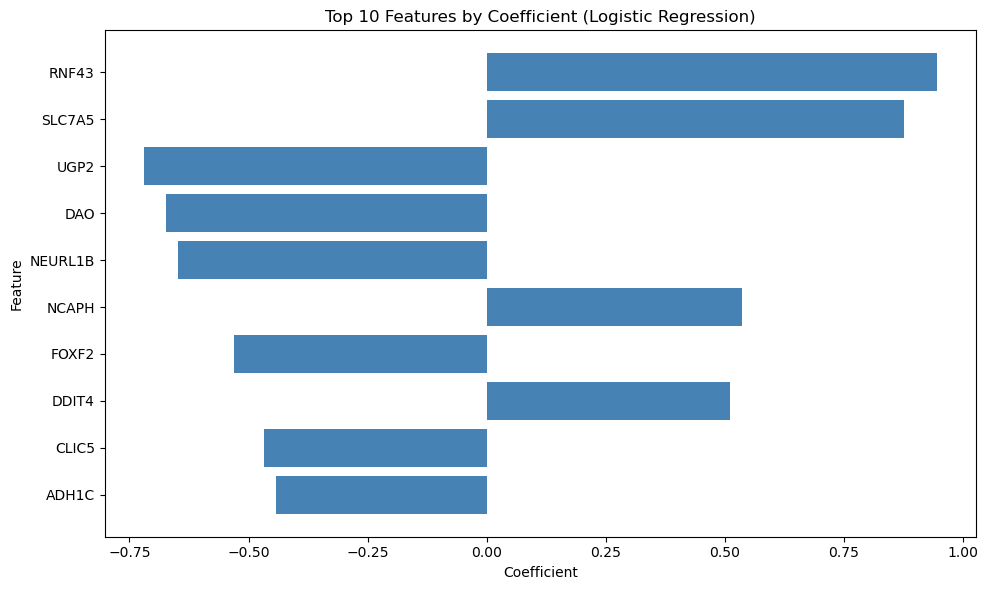

In [7]:
import matplotlib.pyplot as plt 
coef_df_sorted = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

# Chart with the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(coef_df_sorted["Feature"].head(10),
         coef_df_sorted["Coefficient"].head(10),
         color='steelblue')
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features by Coefficient (Logistic Regression)")
plt.gca().invert_yaxis() # Invert to have the largest at the top
plt.tight_layout()
plt.show()

In [8]:
top_features = coef_df_sorted["Feature"].head(3).values
print("Top selected features:", top_features)

Top selected features: ['RNF43' 'SLC7A5' 'UGP2']


In [9]:
# Select only top features
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Normalize again
X_train_top_scaled = scaler.fit_transform(X_train_top)
X_test_top_scaled = scaler.transform(X_test_top)

# Re-training the model
model_top = LogisticRegression(max_iter=10000)
model_top.fit(X_train_top_scaled, y_train)

LogisticRegression(max_iter=10000)

In [10]:
from sklearn.metrics import classification_report, accuracy_score
# Predictions
y_pred = model_top.predict(X_test_top_scaled)

# Evaluation
print("Classification report: \n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification report: 
               precision    recall  f1-score   support

      normal       0.98      1.00      0.99        80
     tumoral       1.00      0.98      0.99        81

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161

Accuracy: 0.9875776397515528


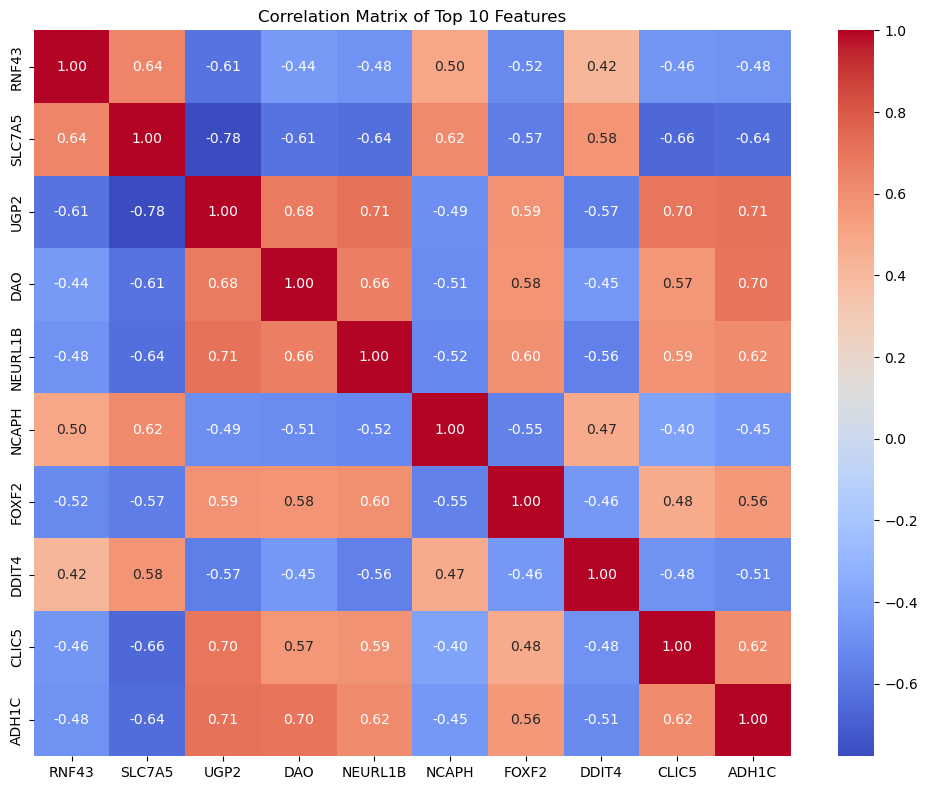

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the 10 most important features
top_10_features = coef_df_sorted["Feature"].head(10).values

# Extract data from these features
X_top10 = df[top_10_features]

# Correlation matrix (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(X_top10.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Top 10 Features")
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Chrun Sample.csv")
df.columns = df.columns.str.strip()
print(df.head())
print(df.info())

X = df.drop(columns=['Exited'])
y = df['Exited']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test_scaled)

print("Classification report: \n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification report: 
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1607
           1       0.40      0.22      0.28       393

    accuracy                           0.78      2000
   macro avg       0.61      0.57      0.58      2000
weighted avg       0.74      0.78      0.76      2000

Accuracy: 0.781


Number of coefficients : 2944
Number of columns in X_encoded : 2944
=== Importance des variables ===
                feature  coefficient  Abscoefficient
3                   Age     0.912430        0.912430
8        IsActiveMember    -0.581301        0.581301
2941  Geography_Germany     0.401879        0.401879
2943        Gender_Male    -0.323430        0.323430
1391      Surname_Kelly    -0.261148        0.261148
250     Surname_Bianchi    -0.230002        0.230002
356      Surname_Buccho    -0.223265        0.223265
5               Balance     0.211805        0.211805
706    Surname_Dellucci    -0.209467        0.209467
2231      Surname_Quinn     0.208576        0.208576


C:\Users\pc-portable.net\AppData\Local\Temp\ipykernel_2988\4186426031.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Abscoefficient', y='feature', data=importance_df.head(10), palette='viridis')


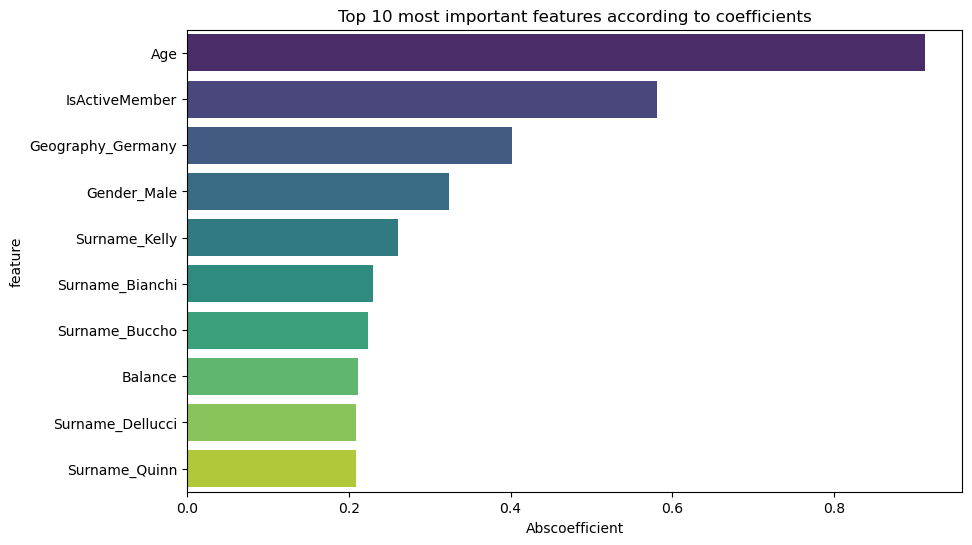

In [15]:
coefficients = model.coef_[0]
features = X_encoded.columns

print(f"Number of coefficients : {len(coefficients)}")
print(f"Number of columns in X_encoded : {len(features)}")

if len(coefficients) != len(features):
    print("There's a mismatch between coefficients and features.")
else:
    importance_df = pd.DataFrame({
        'feature': features,
        'coefficient': coefficients,
        'Abscoefficient': abs(coefficients)
    }).sort_values(by='Abscoefficient', ascending=False)

    print("=== Importance des variables ===")
    print(importance_df.head(10))

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Abscoefficient', y='feature', data=importance_df.head(10), palette='viridis')
    plt.title("Top 10 most important features according to coefficients")
    plt.show()

In [16]:
top_features = importance_df["feature"].head(3).values
print("Top selected features:", top_features)

Top selected features: ['Age' 'IsActiveMember' 'Geography_Germany']


In [17]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

In [18]:
X_train_top_scaled = scaler.fit_transform(X_train_top)
X_test_top_scaled = scaler.transform(X_test_top)

In [19]:
model_top = LogisticRegression(max_iter=10000)
model_top.fit(X_train_top_scaled, y_train)

LogisticRegression(max_iter=10000)

In [20]:
y_pred = model_top.predict(X_test_top_scaled)
print("Classification report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.90      1607
           1       0.63      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.73      0.58      0.59      2000
weighted avg       0.79      0.82      0.78      2000

Accuracy: 0.8185


Top 10 selected features: ['Age' 'IsActiveMember' 'Geography_Germany' 'Gender_Male' 'Surname_Kelly'
 'Surname_Bianchi' 'Surname_Buccho' 'Balance' 'Surname_Dellucci'
 'Surname_Quinn']


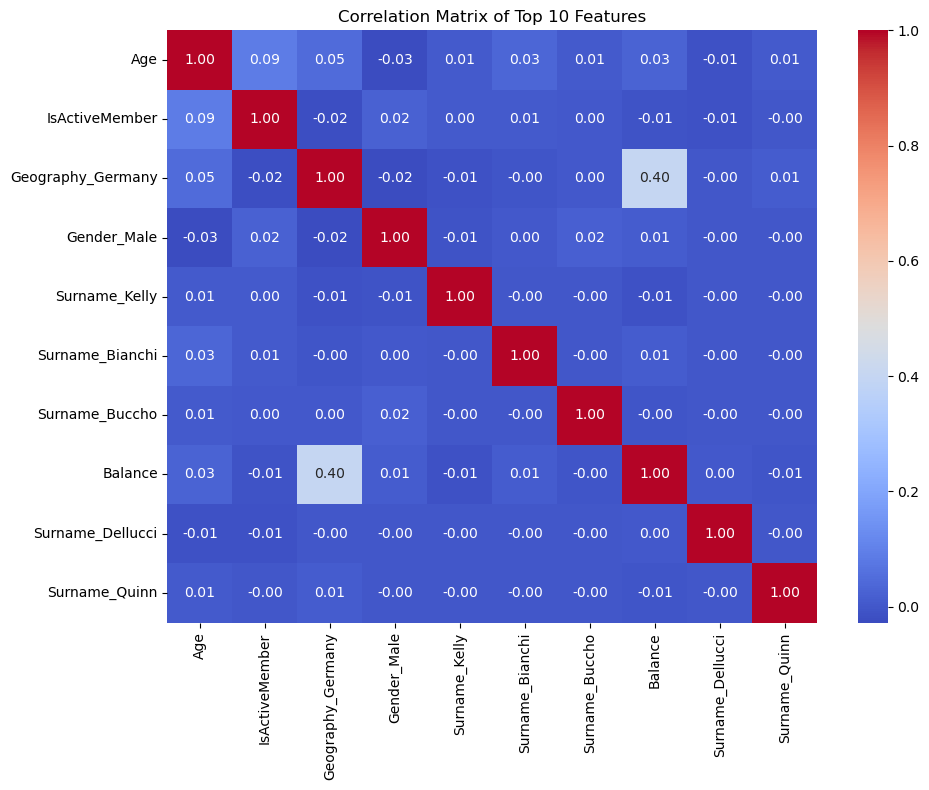

In [21]:
top_10_features = importance_df["feature"].head(10).values
print("Top 10 selected features:", top_10_features)

X_top10 = X_encoded[top_10_features]

plt.figure(figsize=(10, 8))
sns.heatmap(X_top10.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Top 10 Features")
plt.tight_layout()
plt.show()